# 어텐션

앞 장에서는 RNN을 사용해 문장을 생성해봄   
그리고 2개의 RNN을 연결하여 하나의 시계열 데이터를 다른 시계열 데이터로 변환도 해봄   
이를 seq2seq라고 하며, 덧셈 같은 간단한 문제를 푸는 데 성공함   
마지막으로 seq2seq에 몇 가지 개선을 적용한 결과, 간단한 덧셈이라면 거의 완벽하게 풀 수 있음   

이번 장에서는 seq2seq의 가능성 그리고 RNN의 가능성을 더 깊이 살펴봄   
어텐션(Attention)이라는 강력하고 아름다운 기술이 등장할 차례가 온 것   
어텐션은 최근의 딥러닝 분야에서 틀림없이 중요한 기술 중 하나   
이번 장에서 목표로 하는 것은 어텐션의 구조를 코드 수준에서 이해하는 것, 그리고 실제 문제에 적용하여 그 놀라운 효과를 경험하는 것

## 어텐션의 구조

앞 장에서 살펴본 것처럼 seq2seq는 매우 강력한 시스템으로, 다양하게 응용할 수 있음   
이번 장에서는 지금까지 배운 seq2seq를 한층 더 강력하게 하는 **어텐션 메커니즘** 이라는 아이디어를 살펴봄   
이 어텐션이라는 메커니즘 덕분에 seq2seq는 (우리 인간처럼) 필요한 정보에만 '주목'할 수 있게 됨   
게다가 지금까지의 seq2seq가 안고 있던 문제도 해결할 수 있음   

이번 절에서는 현재의 seq2seq가 안고 있는 문제를 먼저 살펴봄   
그 후에 어텐션의 구조를 보면서, 동시에 구현까지 해봄   
그럼 다시, seq2seq가 어떤 일을 수행하는지 생각해봄   

> 앞 장에서도 수행한 seq2seq 개선은 '작은 개선'   
> 이와 달리, 지금부터 설명하는 어텐션 기술은 지금까지의 seq2seq가 안고 있던 근본적인 문제를 해결하는 '큰 개선'

### seq2seq 문제점

seq2seq에서는 Encoder가 시계열 데이터를 인코딩함   
그리고 인코딩된 정보를 Decoder로 전달함   
이때 Encoder의 출력은 '고정 길이의 벡터'   
그런데 이 '고정 길이'라는 데에 큰 문제가 잠재해 있음   
고정 길이 벡터라 함은 입력 문장의 길이에 관계없이(아무리 길어도), 항상 같은 길이의 벡터로 변환한다는 뜻   
앞 장의 번역 예로 설명하면, 아무리 긴 문장이 입력되더라도 항상 똑같은 길이의 벡터에 밀어 넣어야 함   
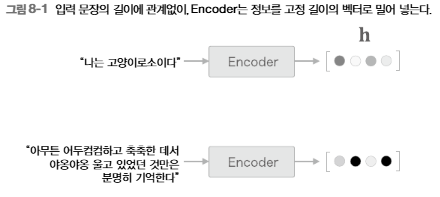   
- 현재의 Encoder는 아무리 긴 문장이라도 고정 길이의 벡터로 변환함   
- 마치 많은 옷가지를 옷장에 욱여넣듯이 억지로 고정 길이의 벡터로 밀어 넣는 것
- 하지만 이렇게 하면 곧 한계가 찾아옴
- 결국에는 옷이 옷장에서 삐져나오듯, 필요한 정보가 벡터에 다 담기지 못하게 됨
- 그러니 우선은 Encoder를 개선하고, 이어서 Decoder도 개선할 예정

### Encoder 개선

지금까지는 LSTM 계층의 마지막 은닉 상태만을 Decoder에 전달했음   
그러나 Encoder 출력의 길이는 입력 문장의 길이에 따라 바꿔주는 게 좋음   
이 점이 Encoder의 개선 포인트   
구체적으로는, 아래 그림처럼 시각별 LSTM 계층의 은닉 상태 벡터를 모두 이용하는 것   
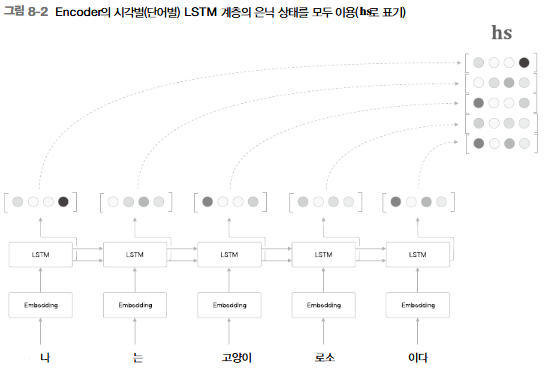   
- 그림처럼 각 시각(각 단어)의 은닉 상태 벡터를 모두 이용하면 입력된 단어와 같은 수의 벡터를 얻을 수 있음
- 그림의 예에서는 5개의 단어가 입력되었고, 이때 Encoder는 5개의 벡터를 출력
- 이것으로 Encoder는 '하나의 고정 길이 벡터'라는 제약으로부터 해방됨   

> 많은 딥러닝 프레임워크에서는 RNN 계층(혹은 LSTM 계층과 GRU 계층 등)을 초기화할 때,   
> '모든 시각의 은닉 상태 벡터 반환'과 '마지막 은닉 상태 벡터만 반환' 중 선택할 수 있음   
> 케라스를 예로 들면, RNN 계층의 초기화 인수로 return_sequences=True로 설정하면 모든 시각의 은닉 상태 벡터를 반환함   

그림에서 주목할 것은 LSTM 계층의 은닉 상태의 '내용'   
LSTM 계층의 각 시각의 은닉 상태에는 직전에 입력된 단어에 대한 정보가 많이 포함되어 있음   
위 그림에서라면, 예컨대 '고양이' 단어를 입력했을 때의 LSTM 계층의 출력(은닉 상태)은 직전에 입력한 '고양이'라는 단어의 영향을 가장 크게 받음   
따라서 이 은닉 상태 벡터는 '고양이'의 '성분'이 많이 들어간 벡터라고 생각할 수 있음   
이렇게 생각하면, Encoder가 출력하는 hs 행렬은 각 단어에 해당하는 벡터들의 집합이라고 볼 수 있음   
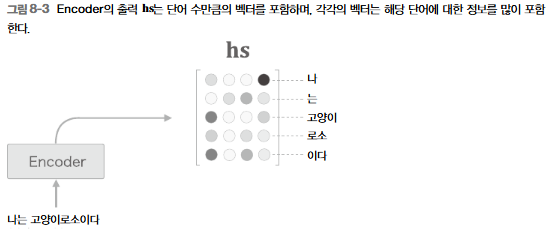   

> Encoder는 왼쪽에서 오른쪽으로 처리하므로, 방금 전의 '고양이' 벡터에는 정확히 총 3개 단어('나', '는', '고양이')의 정보가 담겨 있음   
> 그런데 전체의 균형을 생각하여 '고양이' 단어의 '주변' 정보를 균형 있게 담아야 할 때도 있을 텐데,   
> 그런 경우엔 시계열 데이터를 양방향으로 처리하는 양방향 RNN(혹은 양방향 LSTM)이 효과적   
> 양방향 RNN에 관해서는 나중에 설명하고, 여기에서는 지금까지처럼 단방향 LSTM을 이용할 예정   

여기까지가 Encoder의 개선   
단지 Encoder의 은닉 상태를 모든 시각만큼 꺼냈을 뿐이지만, 이 작은 개선 덕분에 Encoder는 입력 문장의 길이에 비례한 정보를 인코딩할 수 있게 됨   
그럼 이 Encoder의 출력을 Decoder가 어떻게 해야하는지?   
Decoder 개선에 관해서는 내용이 많기 때문에 3개의 절로 나눠 살펴볼 예정

### Deocoder 개선 1

Encoder는 각 단어에 대응하는 LSTM 계층의 은닉 상태 벡터를 hs로 모아 출력함   
그리고 이 hs가 Decoder에 전달되어 시계열 변환이 이뤄짐   
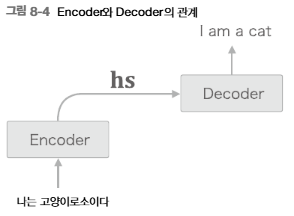   

참고로, 앞 장에서 본 가장 단순한 seq2seq에서는 Encoder의 마지막 은닉 상태 벡터만을 Decoder에 넘겼음   
더 정확하게 말하면, Encoder의 LSTM 계층의 '마지막' 은닉 상태를 Decoder의 LSTM 계층의 '첫' 은닉 상태로 설정한 것   
이 Decoder의 계층 구성은 다음처럼 그릴 수 있음   
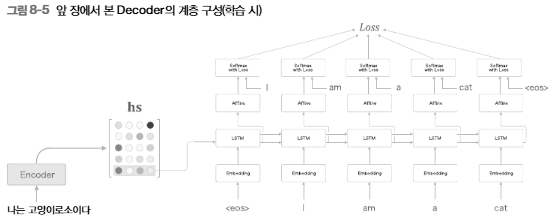   

- 그림에서 보듯 앞 장의 Decoder는 Encoder의 LSTM 계층의 마지막 은닉 상태만을 이용함
- hs에서 마지막 줄만 빼내어 Decoder에 전달한 것   

그럼 이 hs 전부를 활용할 수 있도록 Decoder를 개선해볼 예정   

그런데 사람이 문장을 번역할 때는 머릿속에서 어떤 일이 일어나는지?   
예컨대 "나는 고양이로소이다"를 영어로 번역하려 한다면 아마 대부분이 '나 = I'나 '고양이 = cat'이라는 지식을 이용할 것   
즉, '어떤 단어(혹은 단어의 집합)'에 주목하여 그 단어의 변환을 수시로 하게 될 것   
그러면 이와 같은 과정을 seq2seq로 재현할 수는 없는지?   
더 정확하게 말하면, '입력과 출력의 여러 단어 중 어떤 단어끼리 서로 관련되어 있는가'라는 대응 관계를 seq2seq에게 학습시킬 수는 없을지?   

> 기계 번역의 역사를 보면 '고양이 = cat'과 같은 단어의 대응 관계 지식을 이용하는 연구는 많이 이뤄져 왔음   
> 단어(혹은 문구)의 대응 관계를 나타내는 정보를 **얼라인먼트(alignment)** 라 하는데, 지금까지는 얼라인먼트를 주로 사람이 수작업으로 만들었음   
> 그러나 어텐션 기술은 얼라인먼트라는 아이디어를 seq2seq에 자동으로 도입하는 데 성공했음   
> 이번에도 다시 한번, '수작업'에서 '기계에 의한 자동화'라는 흐름이 이어지고 있음   

앞으로의 목표는 '도착어 단어'와 대응 관계에 있는 '출발어 단어'의 정보를 골라내는 것, 그리고 그 정보를 이용하여 번역을 수행하는 것   
다시 말해, 필요한 정보에만 주목하여 그 정보로부터 시계열 변환을 수행하는 것이 목표   
이 구조를 어텐션이라 부르며, 이번 장의 핵심 주제   

어텐션의 세부 내용으로 들어가기 앞서, 우선 전체 틀을 보면   
앞으로 구현하고자 하는 신경망의 계층 구성은 다음과 같음   
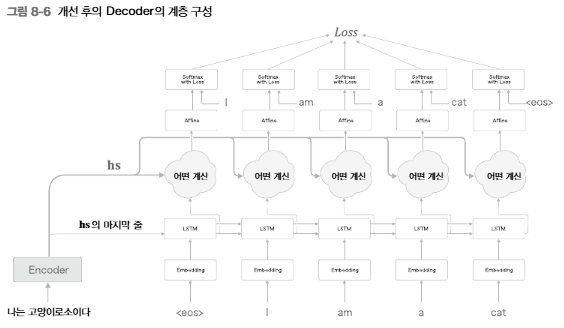   
- 그림처럼 여기에서는 새롭게 '어떤 계산'을 수행하는 계층을 추가할 예정
- 이 '어떤 계산'이 받는 입력은 두 가지로, 하나는 Encoder로부터 받는 hs이고, 다른 하나는 시각별 LSTM 계층의 은닉 상태
- 그리고 여기에서 필요한 정보만 골라 위쪽의 Affine 계층으로 출력함
- 참고로, 지금까지와 똑같이 Encoder의 마지막 은닉 상태 벡터는 Decoder의 첫 번째 LSTM 계층에 전달함
- 그런데 그림의 신경망으로 하고 싶은 일은 단어들의 얼라인먼트 추출
- 각 시각에서 Decoder에 입력된 단어와 대응 관계인 단어의 벡터를 hs에서 골라내겠다는 뜻
- 예컨대 그림의 Decoder가 'I'를 출력할 때, hs에서 '나'에 대응하는 벡터를 선택하면 됨
- 그리고 이러한 '선택' 작업을 '어떤 계산'으로 해내겠다는 것
- 하지만 여기서 문제가 발생하는데 바로 선택하는 작업(여러 대상으로부터 몇 개를 선택하는 작업)은 미분할 수 없다는 점   

> 신경망의 학습은 (일반적으로) 오차역전파법으로 이뤄짐   
> 따라서 미분 가능한 연산으로 신경망을 구축하면 오차역전파법의 틀 안에서 학습을 수행할 수 있음   
> 반대로 미분 가능한 연산을 이용하지 않으면 (기본적으로는) 오차역전파법을 사용할 수 없음   

'선택한다'라는 작업을 미분 가능한 연산으로 대체할 수는 없는지?   
사실 이 문제를 해결할 아이디어는 아주 단순함(그러나 콜럼버스의 달걀처럼 처음으로 생각해내기가 어려운 것)   
그 아이디어란 '하나를 선택'하는 게 아니라, '모든 것을 선택'한다는 것   
그리고 이때 아래 그림과 같이 각 단어의 중요도(기여도)를 나타내는 '가중치'를 별도로 계산하도록 함   
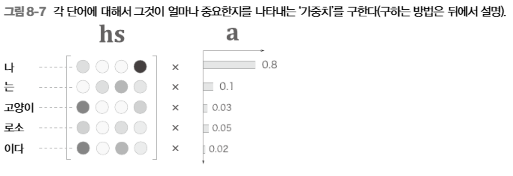   
- 그림에서 보듯, 여기에서는 각 단어의 중요도를 나타내는 '가중치'(기호 a)를 이용함
- a는 확률분포처럼 각 원소가 0.0 ~ 1.0 사이의 스칼라(단일 원소)이며, 모든 원소의 총합은 1이 됨
- 그리고 각 단어의 중요도를 나타내는 가중치 a와 각 단어의 벡터 hs로부터 가중합(weighted sum)을 구하여, 원하는 벡터를 얻음
- 이 일련의 계산을 그려보면 다음 그림처럼 됨   
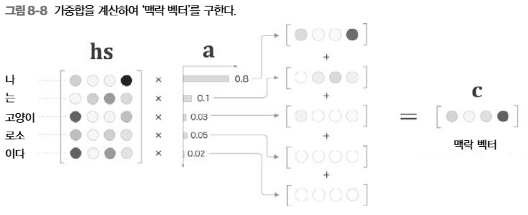   
- 그림처럼 단어 벡터의 가중합을 계산함
- 여기에서는 그 결과를 '맥락 벡터'라고 부르고, 기호로는 c로 표기함
- 그런데 이 그림을 잘 보면 '나'에 대응하는 가중치가 0.8
- 이것이 의미하는 바는 맥락 벡터 c에는 '나' 벡터의 성분이 많이 포함되어 있다는 것
- 즉, '나' 벡터를 '선택'하는 작업을 이 가중합으로 대체하고 있다고 할 수 있음
- 예컨대 '나'에 대응하는 가중치가 1이고 그 외에는 0이라면, '나' 벡터를 '선택'한다고 해석할 수 있음   

> 맥락 벡터 c에는 현 시각의 변환(번역)을 수행하는 데 필요한 정보가 담겨 있음   
> 더 정확하게 말하면, 그렇게 되도록 데이터로부터 학습하는 것   

그럼 여기까지의 내용을 코드로 살펴보면   
Encoder가 출력하는 hs와 각 단어의 가중치 a를 적당하게 작성하고, 그 가중합을 구하는 구현을 볼 수 있음   
다차원 배열의 형상에 주의하면서 살펴보기

In [5]:
import numpy as np

T, H = 5, 4
hs = np.random.randn(T, H)
a = np.array([0.8, 0.1, 0.03, 0.05, 0.02])

ar = a.reshape(5, 1).repeat(4, axis=1)
print(ar.shape)

t= hs * ar
print(t.shape)

c = np.sum(t, axis=0)
print(c.shape)

(5, 4)
(5, 4)
(4,)


- 이 코드는 시계열의 길이를 T = 5, 은닉 상태 벡터의 원소 수를 H = 4로 하여 가중합을 구하는 과정을 보여줌
- 우선은 ar = a.reshape(5, 1).repeat(4, axis=1) 부분에 주목하면
- 이 코드는 아래 그림처럼 a를 ar로 변환함   
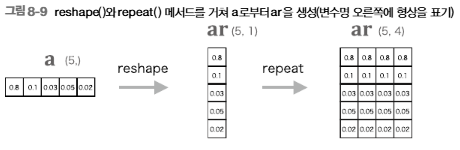   
- 그림처럼 여기서 하고 싶은 것은 형상이 (5,)인 a를 복사하여, (5, 4)짜리 배열을 만드는 것
- 그래서 원래 형상이 (5,)인 a를 a.reshape(5, 1)을 거쳐 (5, 1) 형상으로 성형한 다음, 이 배열의 한 축을 네 번 반복하여 형상이 (5, 4)인 배열을 생성   

> repeat() 메서드는 다차원 배열의 원소를 복사하여 새로운 다차원 배열을 생성함   
> x가 넘파이 다차원 배열일 때, x.repeat(rep, axis) 형태로 사용할 수 있음   
> 인수 rep는 복사를 반복하는 횟수, axis는 반복하는 축(차원)을 지정함   
> 예컨대 x의 형상이 (X, Y, Z)일 때, x.repeat(3, axis=1)을 실행하면 x에서 인덱스가 1인 축(1차원 방향)이 복사되어 형상이 (X, 3 * Y, Z)인 다차원 배열이 만들어짐   

참고로, 여기에서는 repeat() 메서드 대신 넘파이의 브로드캐스트를 사용해도 됨   
즉, ar = a.reshape(5, 1)까지만 한 뒤 곧바로 hs * ar을 계산해도 됨   
이렇게 하면 아래 그림과 같이 hs의 형상과 일치되도록 ar이 자동으로 확장됨   
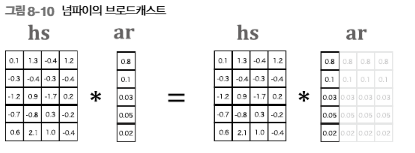   

구현 효율을 생각하면 repeat() 메서드보다는 넘파이의 브로드캐스트를 이용해야 할 것   
다만, 이렇게 하면 다차원 배열의 원소가 복사(반복)되고 있다는 점이 눈에 보이지 않으니 유의   
이전에 '1.3.4 계산 그래프' 절에 따르면, 이 작업은 계산 그래프로는 Repeat 노드에 해당   
따라서 역전파 때는 Repeat 노드의 역전파를 수행해야 함   

위 그림과 같이 원소별 곱을 계산했다면, 그다음은 c = np.sum(hs * ar, axis=0) 코드에서 합을 구함   
여기에서 axis 인수는 어느 축(차원) 방향으로 합을 계산할지를 지정하는 역할   
배열의 형상을 잘 생각해보면 axis 사용법이 명료해짐   
예컨대 x의 형상이 (X, Y, Z)일 때 np.sum(x, axis=1)을 실행하면 출력의 형상은 (X, Z)   
이때 기억할 점은 1번째 축이 '사라진다'는 것   
앞의 예에서 hs * ar의 형상은 (5, 4)이며, 0번째 축을 '사라지게' 했으므로 결과로는 형상이 (4,)인 행렬(벡터)이 구해짐   

> 가중합 계산은 '행렬 곱'을 사용하는 편이 가장 간단하고 효율적   
> 앞의 예로 말하자면 np.matmul(a, hs)라는 한 줄만으로 원하는 결과를 얻을 수 있음   
> 다만, 이 방법은 하나의 데이터(샘플)만 처리하며, 미니배치 처리로 확장하기가 쉽지 않다는 점이 문제   
> 할 수도 있지만, '텐서 곱' 계산이 필요해서 조금 복잡해짐(np.tensordot()과 np.einsum() 메서드를 사용함)   
> 그래서 이 책에서는 행렬 곱을 이용하지 않고, 이해하기 쉽게 구현하고자 repeat()와 sum() 메서드를 이용해 가중합을 구함   

계속해서 미니배치 처리용 가중합을 구현(hs와 a는 무작위로 생성)

In [6]:
N, T, H = 10, 5, 4
hs = np.random.randn(N, T, H)
a = np.random.randn(N, T)
ar = a.reshape(N, T, 1).repeat(H, axis=2)
# ar = a.reshape(N, T, 1)  # 브로드캐스트를 사용하는 경우

t = hs * ar
print(t.shape)

c= np.sum(t, axis=1)
print(c.shape)

(10, 5, 4)
(10, 4)


- 여기에서의 미니배치 처리는 이전 구현과 거의 같음
- 배열의 형상을 잘 살펴보면 repeat()와 sum()에서 어느 차원(축)을 지정해야 하는지 곧 알 수 있을 것   

그럼, 지금까지의 정리도 겸해, 가중합 계산을 '계산 그래프'로 그려보면   
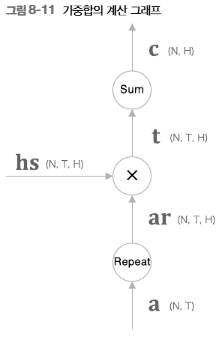   
- 그림에서 보듯, 여기에서는 Repeat 노드를 사용해 a를 복제함
- 이어서 'x' 노드로 원소별 곱을 계산한 다음 Sum 노드로 합을 구함   

이 계산 그래프의 역전파도 살펴보면   
필요한 정보는 이미 다 공부했음, Repeat 노드와 Sum 노드의 역전파는 1장에서 살펴봄   
'Repeat의 역전파는 Sum'이고 'Sum의 역전파는 Repea'   
텐서의 형상에 주의하여 살펴보면 어떤 축에 대한 Sum인지, 어느 축에 대한 Repeat인지도 금방 알 수 있음   

그러면 위 그림의 계산 그래프를 계층으로 구현해보면   
이 계층을 Weight Sum 계층이라 부르기로 하고, 코드로는 다음처럼 구현할 수 있음

In [7]:
class WeightSum:
    def __init__(self):
        self.params, self.grads = [], []
        self.cache = None

    def forward(self, hs, a):
        N, T, H = hs.shape

        ar = a.reshape(N, T, 1).repeat(H, axis=2)
        t = hs * ar
        c = np.sum(t, axis=1)

        self.cache = (hs, ar)
        return c

    def backward(self, dc):
        hs,ar = self.cache
        N, T, H = hs.shape

        dt = dc.reshape(N, 1, H).repeat(T, axis=1)  # sum의 역전파
        dar = dt * hs
        dhs = dt * ar
        da = np.sum(dar, axis=2)  # repeat의 역전파

        return dhs, da

- 이것이 맥락 벡터를 구하는 Weight Sum 계층의 구현
- 이 계층은 학습하는 매개변수가 없으므로, 이 책의 구현 규칙에 따라 self.params = []로 설정
- 그 뒤로는 특별히 어려운 점은 없음   

그럼 다음 단계로 넘어감

### Decoder 개선 2

각 단어의 중요도를 나타내는 가중치 a가 있다면, 가중합을 이용해 '맥락 벡터'를 얻을 수 있음   
그런데 이 a는 어떻게 구해야 하는지?   
물론, 사람이 손수 지정하는 일은 하지 않음   
당연히 데이터로부터 자동으로 학습할 수 있도록 준비해야 함   

그럼, 각 단어의 가중치 a를 구하는 방법을 살펴봄   
우선 Decoder의 첫 번째(시각) LSTM 계층이 은닉 상태 벡터를 출력할 때까지의 처리부터 알아봐야 함   
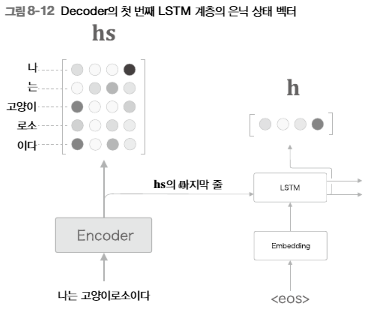   
- 그림에서는 Decoder의 LSTM 계층의 은닉 상태 벡터를 h라 함
- 지금 목표는 이 h가 hs의 각 단어 벡터와 얼마나 '비슷한가'를 수치로 나타내는 것
- 방법은 여러 가지가 있지만, 여기에서는 가장 단순한 방법인 벡터의 '내적'을 이용하고자 함
- 참고로 두 벡터 a=(a1,a2,...,an)와 b=(b1,b2,...,bn)의 내적은 다음과 같이 계산함   
   
- 내적은 위 식으로 표현되며, 그 직관적인 의미는 '두 벡터가 얼마나 같은 방향을 향하고 있는가'
- 따라서 두 벡터의 '유사도'를 표현하는 척도로 내적을 이용하는 것은 자연스러운 선택이라고 할 수 있음   

> 벡터의 유사도를 계산하는 방법은 내적 말고도 여러 가지가 있음   
> 예컨대 유사도 점수를 출력하는 작은 신경망을 사용하는 사례도 있음   

그럼 내적을 이용해 벡터 사이의 유사도를 산출할 때까지의 처리를 그림으로 살펴보면   
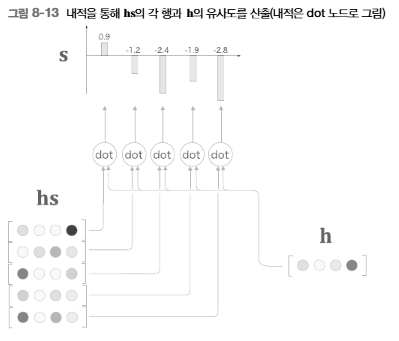   
- 그림에서 보듯, 여기에서는 벡터의 내적을 이용해 h와 hs의 각 단어 벡터와의 유사도를 구함
- 그리고 s는 그 결과
- 참고로 s는 정규화하기 전의 값이며, '점수(score)'라고도 함   

계속해서 s를 정규화하기 위해서는 일반적으로 소프트맥스 함수를 적용함   
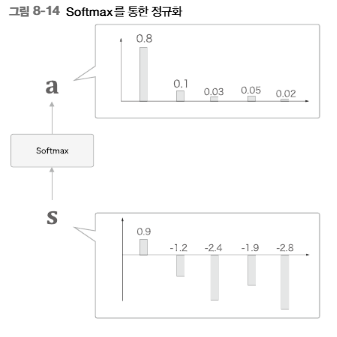   
소프트맥스 함수를 이용하면 그 출력인 a의 각 원소는 0.0 ~ 1.0 사이의 값이 되고, 모든 원소의 총합은 1이 됨   
여기까지 각 단어의 가중치를 나타내는 a를 구해냈음   
그럼, 지금까지의 과정을 코드로 살펴보면

In [8]:
import sys
sys.path.append('..')
from common.layers import Softmax
import numpy as np

N, T, H = 10, 5, 4
hs = np.random.randn(N, T, H)
h = np.random.randn(N, H)
hr = h.reshape(N, 1, H).repeat(T, axis=1)
# hr = h.reshape(N, 1, H)  # 브로드캐스트를 사용하는 경우

t = hs * hr
print(t.shape)

s = np.sum(t, axis=2)
print(s.shape)

softmax = Softmax()
a = softmax.forward(s)
print(a.shape)

(10, 5, 4)
(10, 5)
(10, 5)


- 이 구현은 미니배치 처리를 수행할 때의 코드
- 여기에서도 reshape()와 repeat() 메서드를 이용해 적합한 형상의 hr을 생성함
- 참고로, 넘파이의 브로드캐스트를 사용한다면 repeat()는 필요 없음   

그러면 이 과정을 계산 그래프로 보면   
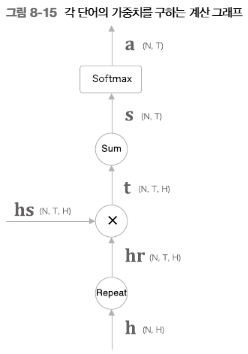   
- 그림과 같이 이 계산 그래프는 Repeat 노드, 원소별 곱을 뜻하는 x 노드, Sum 노드, 그리고 Softmax 계층으로 구성됨
- 이 계산 그래프가 표현하는 처리는 AttentionWeight 클래스로 구현

In [9]:
import sys
sys.path.append('..')
from common.np import *  # import numpy as np
from common.layers import Softmax


class AttentionWeight:
    def __init__(self):
        self.params, self.grads = [], []
        self.softmax = Softmax()
        self.cache = None

    def forward(self, hs, h):
        N, T, H = hs.shape

        hr = h.reshape(N, 1, H).repeat(T, axis=1)
        t = hs * hr
        s = np.sum(t, axis=2)
        a = self.softmax.forward(s)

        self.cache = (hs, hr)
        return a

    def backward(self, da):
        hs, hr = self.cache
        N, T, H = hs.shape

        ds = self.softmax.backward(da)
        dt = ds.reshape(N, T, 1).repeat(H, axis=2)
        dhs = dt * hr
        dhr = dt * hs
        dh = np.sum(dhr, axis=1)

        return dhs, dh

- 이 구현에서도 이전 Weight Sum 계층의 구현과 마찬가지로 Repeat와 Sum 연산이 등장함
- 역전파에서는 이 두 연산만 주의하면 다른 어려움은 없음   

그럼 계속해서 Decoder 개선의 마지막 단계로 나아감

### Decoder 개선 3

지금까지 Decoder 개선안을 두 가지로 나눠 살펴봄   
Attention Weight 계층, Weight Sum 계층을 각각 구현했음   
이제 이 두 계층을 하나로 결합   
결과는 다음과 같음   
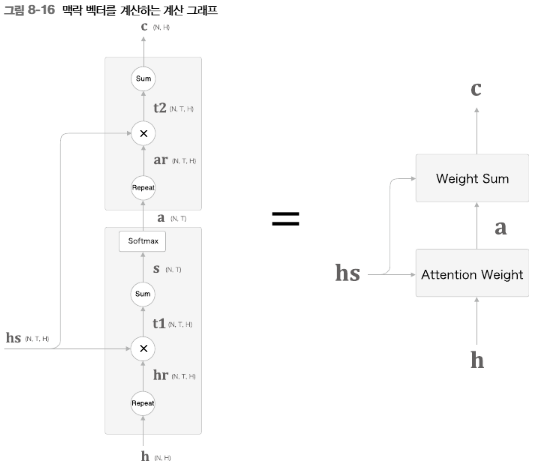   
- 그림이 맥락 벡터를 구하는 계산 그래프의 전체 모습
- 이 계산을 Weight Sum 계층과 Attention Weight 계층, 2개로 나눠 구현했음
- 이 계산에 따르면 Attention Weight 계층은 Encoder가 출력하는 각 단어의 벡터 hs에 주목하여 해당 단어의 가중치 a를 구함
- 이어서 Weight Sum 계층이 a와 hs의 가중합을 구하고, 그 결과를 맥락 벡터 c로 출력
- 이 일련의 계산을 수행하는 계층을 Attention 계층이라고 부름   
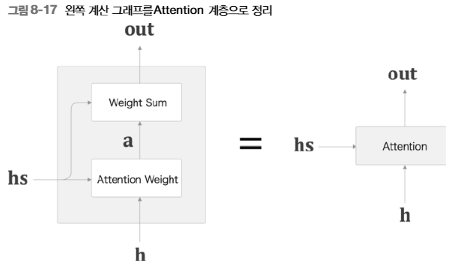   

여기까지가 어텐션 기술의 핵심   
Encoder가 건네주는 정보 hs에서 중요한 원소에 주목하여, 그것을 바탕으로 맥락 벡터를 구해 위쪽 계층으로 전파함(여기서는, 위쪽에는 Affine 계층이 기다리고 있음)   
그럼 Attention 계층을 구현한 코드를 보면

In [10]:
class Attention:
    def __init__(self):
        self.params, self.grads = [], []
        self.attention_weight_layer = AttentionWeight()
        self.weight_sum_layer = WeightSum()
        self.attention_weight = None

    def forward(self, hs, h):
        a = self.attention_weight_layer.forward(hs, h)
        out = self.weight_sum_layer.forward(hs, a)
        self.attention_weight = a
        return out

    def backward(self, dout):
        dhs0, da = self.weight_sum_layer.backward(dout)
        dhs1, dh = self.attention_weight_layer.backward(da)
        dhs = dhs0 + dhs1
        return dhs, dh

- 이 코드는 2개의 계층(Weight Sum 계층과 Attention Weight 계층)에 의한 순전파와 역전파를 수행할 뿐
- 이때 각 단어의 가중치를 나중에 참조할 수 있도록 attention_weight라는 인스턴스 변수에 저장   

Attention 계층의 구현은 끝   
이제 이 Attention 계층을 LSTM 계층과 Affine 계층 사이에 삽입하면 됨   
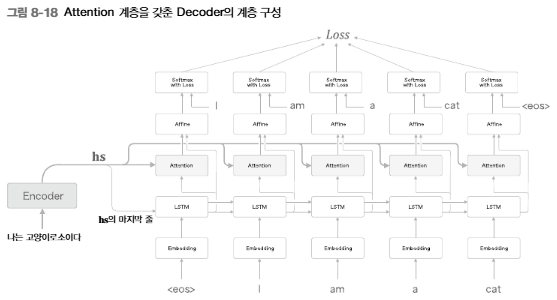   
- 그림에서 보듯, 각 시각의 Attention 계층에는 Encoder의 출력인 hs가 입력됨
- 또 여기에서는 LSTM 계층의 은닉 상태 벡터를 Affine 계층에 입력함
- 이는 앞 장에서 본 Decoder의 개선으로부터 자연스럽게 확장된 것
- 그림처럼 앞 장의 Decoder에 어텐션 정보를 '추가'할 수 있기 때문   

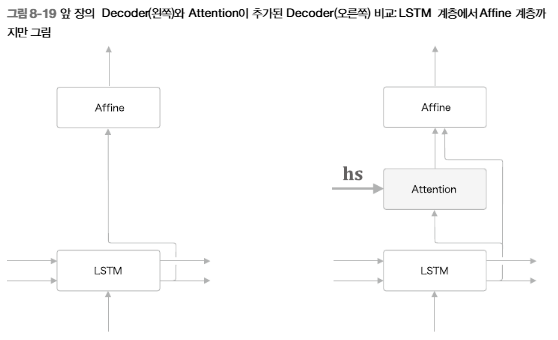   
- 그림의 오른쪽은 앞 장의 Decoder에 Attention 계층이 구한 맥락 벡터 정보를 '추가'한 것
- Affine 계층에는 기존과 마찬가지로 LSTM 계층의 은닉 상태 벡터를 주고, 여기에 더해 Attention 계층의 맥락 벡터까지 입력하는 것   

> 그림에서는 Affine 계층에 '맥락 벡터'와 '은닉 상태 벡터'라는 2개의 벡터가 입력되었음   
> 이는 (앞에서도 설명한 것처럼) 두 벡터를 '연결한 벡터'를 Affine 계층에 입력한다는 뜻   

마지막으로 시계열 방향으로 펼쳐진 다수의 Attention 계층을 Time Attention 계층으로 모아 구현   
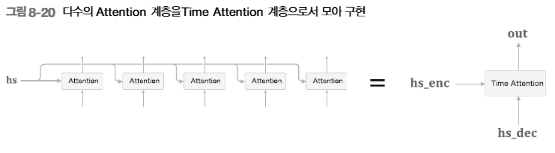   
- 그림에서 보듯 Time Attention 계층은 다수의 Attention 계층을 모았을 뿐   

그럼, Time Attention 계층의 구현을 보면

In [11]:
class TimeAttention:
    def __init__(self):
        self.params, self.grads = [], []
        self.layers = None
        self.attention_weights = None

    def forward(self, hs_enc, hs_dec):
        N, T, H = hs_dec.shape
        out = np.empty_like(hs_dec)
        self.layers = []
        self.attention_weights = []

        for t in range(T):
            layer = Attention()
            out[:, t, :] = layer.forward(hs_enc, hs_dec[:,t,:])
            self.layers.append(layer)
            self.attention_weights.append(layer.attention_weight)

        return out

    def backward(self, dout):
        N, T, H = dout.shape
        dhs_enc = 0
        dhs_dec = np.empty_like(dout)

        for t in range(T):
            layer = self.layers[t]
            dhs, dh = layer.backward(dout[:, t, :])
            dhs_enc += dhs
            dhs_dec[:,t,:] = dh

        return dhs_enc, dhs_dec

- Attention 계층을 필요한 수만큼 만들고(코드에서는 T개), 각각이 순전파와 역전파를 수행
- 또한, 각 Attention 계층의 각 단어의 가중치를 attention_weights 리스트에서 보관   

이상으로 어텐션 구조를 구현까지 마침   
이어서 어텐션을 사용해 seq2seq를 구현하고, 현실적인 문제에 도전하여 그 효과를 확인해볼 예정

## 어텐션을 갖춘 seq2seq 구현

앞 절에서 Attention 계층(및 Time Attention 계층)의 구현을 끝냄   
이번 절에서는 이 계층을 사용해 '어텐션을 갖춘 seq2seq'를 구현   
실제로는 앞 장과 마찬가지로 3개의 클래스(Encoder, Decoder, seq2seq)를 구현하는데,   
이번에는 그 이름이 차례로 AttentionEncoder, AttentionDecoder, AttentionSeq2seq

### Encoder 구현

AttentionEncoder 클래스부터 구현   
이 클래스는 앞 장에서 구현한 Encoder 클래스와 거의 같음   
앞 장의 Encoder 클래스의 forward() 메서드는 LSTM 계층의 마지막 은닉 상태 벡터만을 반환했음   
그에 반해, 이번에는 모든 은닉 상태를 반환 - 이 점이 유일한 차이   
그래서 앞 장의 Encoder를 상속하여 구현   
AttentionEncoder 클래스의 코드를 보면

In [12]:
import sys
sys.path.append('..')
from common.time_layers import *
from ch08.seq2seq import Encoder, Seq2seq

class AttentionEncoder(Encoder):
    def forward(self, xs):
        xs = self.embed.forward(xs)
        hs = self.lstm.forward(xs)
        return hs

    def backward(self, dhs):
        dout = self.lstm.backward(dhs)
        dout = self.embed.backward(dout)
        return dout

### Decoder 구현

이어서 Attention 계층을 이용한 Decoder의 구현   
어텐션을 이용한 Decoder의 계층 구성은 다음과 같음   
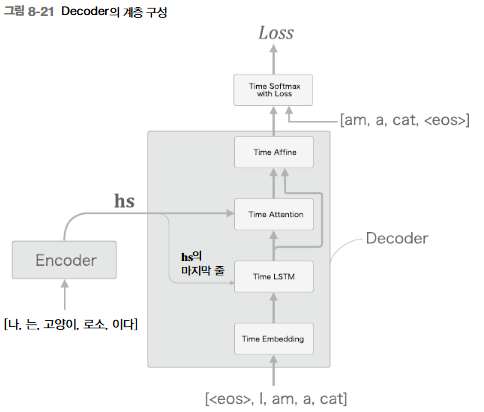   
- 그림에서 보듯, 앞 장의 구현과 마찬가지로 Softmax 계층(정확히는 Time Softmax with Loss 계층)의 앞까지를 Decoder로 구현
- 역시 앞 장과 마찬가지로, 순전파의 forward()와 역전파의 backward() 메서드뿐 아니라 새로운 단어열(혹은 문자열)을 생성하는 generate() 메서드도 추가

In [13]:
class AttentionDecoder:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        embed_W = (rn(V, D) / 100).astype('f')
        lstm_Wx = (rn(D, 4 * H) / np.sqrt(D)).astype('f')
        lstm_Wh = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_b = np.zeros(4 * H).astype('f')
        affine_W = (rn(2*H, V) / np.sqrt(2*H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        self.embed = TimeEmbedding(embed_W)
        self.lstm = TimeLSTM(lstm_Wx, lstm_Wh, lstm_b, stateful=True)
        self.attention = TimeAttention()
        self.affine = TimeAffine(affine_W, affine_b)
        layers = [self.embed, self.lstm, self.attention, self.affine]

        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, xs, enc_hs):
        h = enc_hs[:,-1]
        self.lstm.set_state(h)

        out = self.embed.forward(xs)
        dec_hs = self.lstm.forward(out)
        c = self.attention.forward(enc_hs, dec_hs)
        out = np.concatenate((c, dec_hs), axis=2)
        score = self.affine.forward(out)

        return score

    def backward(self, dscore):
        dout = self.affine.backward(dscore)
        N, T, H2 = dout.shape
        H = H2 // 2

        dc, ddec_hs0 = dout[:,:,:H], dout[:,:,H:]
        denc_hs, ddec_hs1 = self.attention.backward(dc)
        ddec_hs = ddec_hs0 + ddec_hs1
        dout = self.lstm.backward(ddec_hs)
        dh = self.lstm.dh
        denc_hs[:, -1] += dh
        self.embed.backward(dout)

        return denc_hs
    
    def generate(self, enc_hs, start_id, sample_size):
        sampled = []
        sample_id = start_id
        h = enc_hs[:, -1]
        self.lstm.set_state(h)

        for _ in range(sample_size):
            x = np.array([sample_id]).reshape((1, 1))

            out = self.embed.forward(x)
            dec_hs = self.lstm.forward(out)
            c = self.attention.forward(enc_hs, dec_hs)
            out = np.concatenate((c, dec_hs), axis=2)
            score = self.affine.forward(out)

            sample_id = np.argmax(score.flatten())
            sampled.append(sample_id)

        return sampled

- 이 구현은 Time Attention 계층이 새롭게 사용되는 것을 제외하면 앞 장의 Decoder 클래스와 크게 다르지 않음
- forward() 메서드에서 Time Attention 계층의 출력과 LSTM 계층의 출력을 연결한다는 점만 주의
- 두 출력을 연결할 때는 np.concatenate() 메서드를 사용   

이어서 마지막으로 AttentionEncoder 클래스와 AttentionDecoder 클래스를 결합하여 AttentionSeq2seq 클래스를 완성해볼 예정

### seq2seq 구현

AttentionSeq2seq 클래스의 구현도 앞 장에서 본 Seq2seq와 거의 같음   
다른 점은 Encoder 대신 AttentionEncoder 클래스를, Decoder 대신 AttentionDecoder 클래스를 사용하는 것뿐   
따라서 앞 장의 Seq2seq 클래스를 상속하고, 초기화 메서드를 수정하는 것만으로 AttentionSeq2seq 클래스를 구현할 수 있음

In [14]:
class AttentionSeq2seq(Seq2seq):
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        args = vocab_size, wordvec_size, hidden_size
        self.encoder = AttentionEncoder(*args)
        self.decoder = AttentionDecoder(*args)
        self.softmax = TimeSoftmaxWithLoss()

        self.params = self.encoder.params + self.decoder.params
        self.grads = self.encoder.grads + self.decoder.grads

## 어텐션 평가

앞 절에서 구현한 AttentionSeq2seq 클래스를 사용해 현실적인 문제에 도전   
원래대로면 번역 문제를 가져와 어텐션의 효과를 확인하려 했지만, 번역용 데이터셋 중에는 크기가 적당한 것이 없음   
그래서 이 책에서는 '날짜 형식'을 변경하는 문제(데이터 크기가 작고, 어느 쪽인가를 맞추는 인위적인 문제)로 어텐션을 갖춘 seq2seq의 효과를 확인해보려 함   

> 번역용 데이터셋 중에는 'WMT'가 유명   
> 이 데이터셋에는 영어와 프랑스어(또는 영어와 독일어) 학습 데이터가 쌍으로 준비되어 있음   
> WMT 데이터셋은 많은 연구에서 벤치마크로 이용되고 있으며, seq2seq의 성능을 평가하는 데도 자주 이용됨   
> 다만, 덩치가 커서(20GB 이상) 부담이 됨   

### 날짜 형식 변환 문제

이번 절에서 '날짜 형식 변환' 문제를 살펴볼 것   
영어권에서 사용되는 다양한 날짜 형식을 표준 형식으로 변환하는 것이 목표   
예컨대 아래 그림처럼, 사람이 쓴 "september 27, 1994" 등의 날짜 데이터를 "1994-09-27" 같은 표준 형식으로 변환   
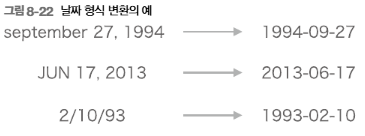   
- 날짜 형식 변환 문제를 채용한 데는 두 가지 이유가 있음
- 하나는 이 문제가 겉보기만큼 간단하지 않다는 점
    - 입력되는 날짜 데이터에는 다양한 변형이 존재하여 변환 규칙이 나름 복잡해지기 때문
    - 만약 그 변환 규칙을 사람이 수작업으로 모두 써내려면 매우 귀찮고 복잡한 작업이 될 것
- 두 번째 이유는 문제의 입력(질문)과 출력(답변) 사이에 알기 쉬운 대응 관계가 있기 때문
    - 구체적으로 말하면, 년,월,일의 대응 관계가 존재
    - 따라서 어텐션이 각각의 원소에 올바르게 주목하고 있는지를 확인할 수 있음   

여기서 사용할 날짜 형식 변환 데이터는 dataset/date.txt에 준비되어 있음   
이 텍스트 파일은 아래 그림과 같은 형태의 날짜 변환 학습 데이터를 50,000개 담고 있음   
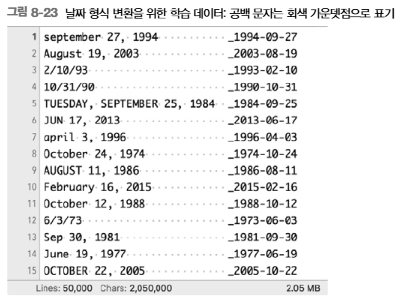   
- 이 학습 데이터의 형식을 확인해보면
- 그림에서 보듯 이 데이터셋은 입력 문장의 길이를 통일하기 위해 공백 문자로 패딩해뒀고, 입력과 출력의 구분 문자로는 '_'(밑줄)을 사용
- 그리고 이 문제에서는 출력의 문자 수는 일정하기 때문에 출력의 끝을 알리는 구분 문자는 따로 사용하지 않음   

> 이 책에서는 이와 같은 seq2seq용 학습 데이터를 파이썬에서 쉽게 처리할 수 있도록 전용 모듈을 제공   
> 이 모듈의 위치는 dataset/sequence.py

### 어텐션을 갖춘 seq2seq의 학습

그럼, 날짜 변환용 데이터셋으로 AttentionSeq2seq를 학습시켜보면

| 에폭 1 |  반복 1 / 351 | 시간 0[s] | 손실 4.08
| 에폭 1 |  반복 21 / 351 | 시간 4[s] | 손실 3.09
| 에폭 1 |  반복 41 / 351 | 시간 9[s] | 손실 1.90
| 에폭 1 |  반복 61 / 351 | 시간 14[s] | 손실 1.72
| 에폭 1 |  반복 81 / 351 | 시간 19[s] | 손실 1.46
| 에폭 1 |  반복 101 / 351 | 시간 24[s] | 손실 1.19
| 에폭 1 |  반복 121 / 351 | 시간 28[s] | 손실 1.14
| 에폭 1 |  반복 141 / 351 | 시간 33[s] | 손실 1.09
| 에폭 1 |  반복 161 / 351 | 시간 37[s] | 손실 1.06
| 에폭 1 |  반복 181 / 351 | 시간 42[s] | 손실 1.04
| 에폭 1 |  반복 201 / 351 | 시간 47[s] | 손실 1.03
| 에폭 1 |  반복 221 / 351 | 시간 51[s] | 손실 1.02
| 에폭 1 |  반복 241 / 351 | 시간 56[s] | 손실 1.02
| 에폭 1 |  반복 261 / 351 | 시간 61[s] | 손실 1.01
| 에폭 1 |  반복 281 / 351 | 시간 65[s] | 손실 1.00
| 에폭 1 |  반복 301 / 351 | 시간 70[s] | 손실 1.00
| 에폭 1 |  반복 321 / 351 | 시간 74[s] | 손실 1.00
| 에폭 1 |  반복 341 / 351 | 시간 79[s] | 손실 1.00
Q 10/15/94                     
T 1994-10-15
X 1978-08-11
---
Q thursday, november 13, 2008  
T 2008-11-13
X 1978-08-11
---
Q Mar 25, 2003                 
T 2003-03-25
X 1978-08-11
---
Q Tuesday, November 22, 2016   

c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54253 (\N{HANGUL SYLLABLE POG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL 

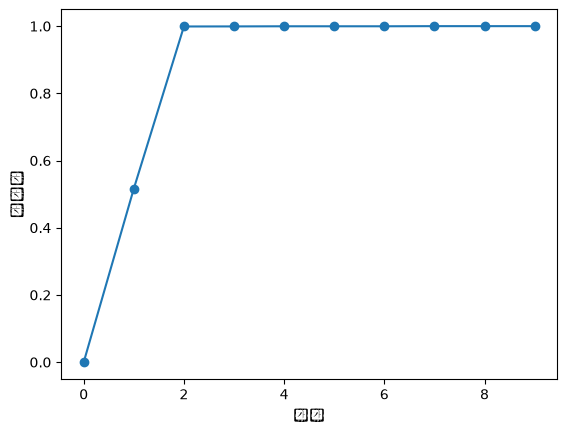

In [15]:
import sys
sys.path.append('..')
sys.path.append('../ch07')
import numpy as np
import matplotlib.pyplot as plt
from dataset import sequence
from common.optimizer import Adam
from common.trainer import Trainer
from common.util import eval_seq2seq
from seq2seq import Seq2seq
from peeky_seq2seq import PeekySeq2seq


# 데이터 읽기
(x_train, t_train), (x_test, t_test) = sequence.load_data('date.txt')
char_to_id, id_to_char = sequence.get_vocab()

# 입력 문장 반전
x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]

# 하이퍼파라미터 설정
vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 256
batch_size = 128
max_epoch = 10
max_grad = 5.0

model = AttentionSeq2seq(vocab_size, wordvec_size, hidden_size)
# model = Seq2seq(vocab_size, wordvec_size, hidden_size)
# model = PeekySeq2seq(vocab_size, wordvec_size, hidden_size)

optimizer = Adam()
trainer = Trainer(model, optimizer)

acc_list = []
for epoch in range(max_epoch):
    trainer.fit(x_train, t_train, max_epoch=1,
                batch_size=batch_size, max_grad=max_grad)

    correct_num = 0
    for i in range(len(x_test)):
        question, correct = x_test[[i]], t_test[[i]]
        verbose = i < 10
        correct_num += eval_seq2seq(model, question, correct,
                                    id_to_char, verbose, is_reverse=True)

    acc = float(correct_num) / len(x_test)
    acc_list.append(acc)
    print('정확도 %.3f%%' % (acc * 100))


model.save_params()

# 그래프 그리기
x = np.arange(len(acc_list))
plt.plot(x, acc_list, marker='o')
plt.xlabel('에폭')
plt.ylabel('정확도')
plt.ylim(-0.05, 1.05)
plt.show()

- 이 코드는 앞 장에서 본 '덧셈'의 학습용 코드와 거의 같음
- 다른 점은 학습 데이터가 날짜 데이터라는 것, 그리고 모델로 AttentionSeq2seq를 사용한다는 것
- 그리고 입력 문장을 반전시키는 기법(Reverse)도 적용
- 그런 다음 학습을 수행하면서, 에폭마다 테스트 데이터를 사용하여 정답률을 측정
- 이때 처음 10 문제의 결과는 (질문 문장과 정답도 함께) 터미널에 출력   

코드를 실행해보면   
학습이 진행되면서 아래 그림과 같은 결과가 나타남   
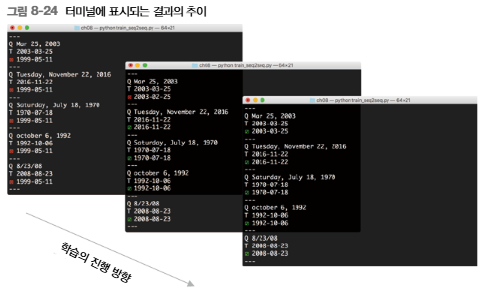   
- 그림에서 보듯, 어텐션을 갖춘 seq2seq는 학습을 거듭할수록 점점 똑똑해짐
- 얼마 지나지 않아 문제 대부분을 정확히 맞추게 됨
- 그리고 테스트 데이터로 얻은 정답률(이 코드의 acc_list)을 그래프로 그리면   

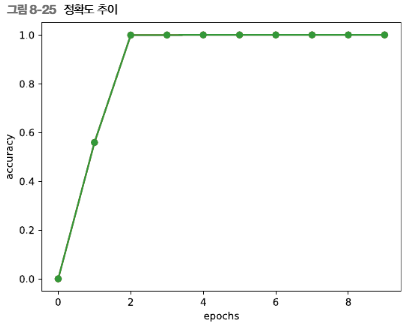   
- 그림에서 보듯 1 에폭부터 빠르게 정답률을 높여 2 에폭째에는 이미 거의 모든 문제를 풀어냄
- 아주 좋은 결과라고 할 수 있음
- 그럼 이 결과를 앞 장의 모델과 비교해보면   

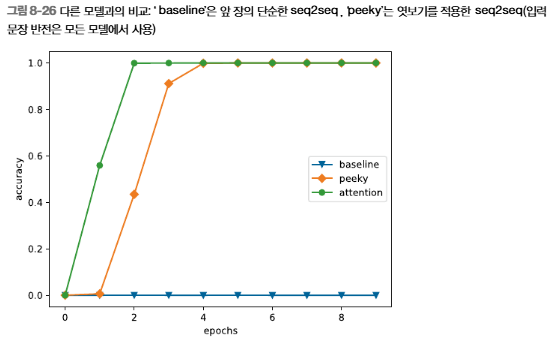   
- 그림의 결과를 보면 단순한 seq2seq(그래프의 baseline)는 전혀 쓸모가 없음을 알 수 있음
- 10 에폭을 지나도 문제를 거의 풀지 못함
- 한편, '엿보기'를 사용한 Peeky는 좋은 결과를 보여줌
- 이 모델은 3 에폭부터 정답률을 높여, 4 에폭째부터 100%에 도달
- 하지만 학습 속도는 어텐션 쪽이 약간 우세   

이번 실험에서 최종 정확도 측면에서는 어텐션과 Peeky가 동등   
그러나 현실의 시계열 데이터는 길고 복잡하므로, 학습 속도뿐 아니라 정확도 역시 어텐션이 유리할 것

### 어텐션 시각화

이어서 어텐션을 시각화   
어텐션이 시계열 변환을 수행할 때, 어느 원소에 주의를 기울이는지를 눈으로 살펴보려는 시도   
Attention 계층은 각 시각의 어텐션 가중치를 인스턴스 변수로 보관하고 있으므로, 이를 시각화하기란 아주 간단   

이 책의 구현에서는 Time Attention 계층에 있는 인스턴스 변수 attention_weights에 각 시각의 어텐션 가중치가 저장됨   
이것을 사용하면 입력 문장과 출력 문장의 단어 대응 관계를 2차원 맵으로 그릴 수 있음   
그래서 이번 절에서는 학습이 끝난 AttentionSeq2seq로 날짜 변환을 수행할 때의 어텐션 가중치를 시각화   

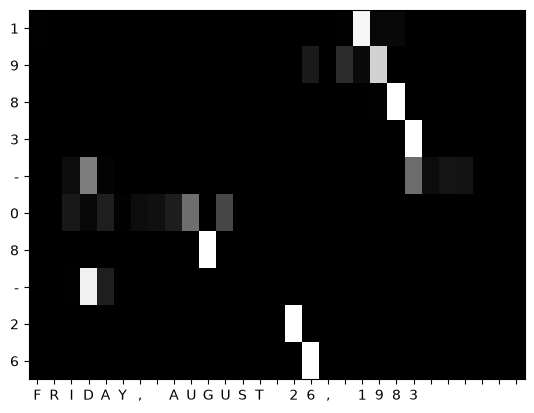

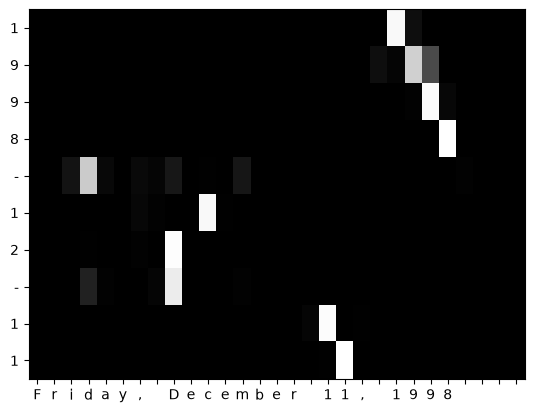

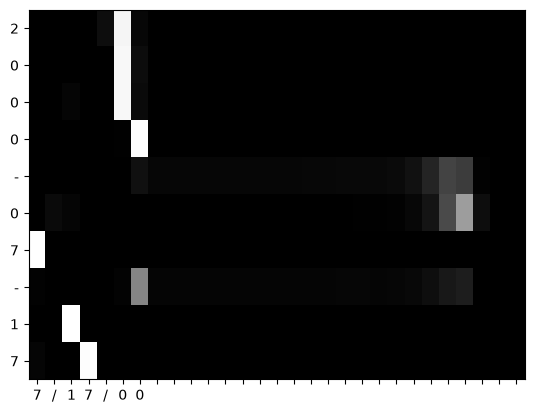

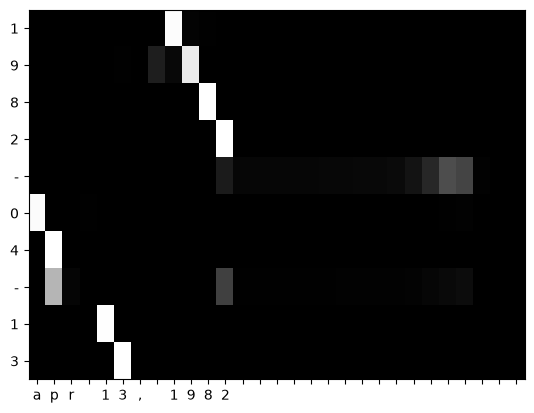

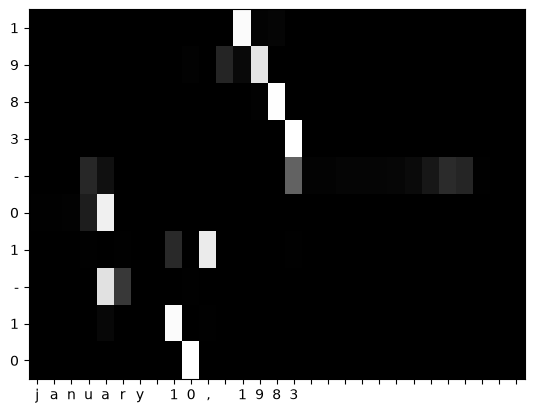

In [16]:
import sys
sys.path.append('..')
import numpy as np
from dataset import sequence
import matplotlib.pyplot as plt


(x_train, t_train), (x_test, t_test) = \
    sequence.load_data('date.txt')
char_to_id, id_to_char = sequence.get_vocab()

# 입력 문장 반전
x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]

vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 256

model = AttentionSeq2seq(vocab_size, wordvec_size, hidden_size)
model.load_params()

_idx = 0
def visualize(attention_map, row_labels, column_labels):
    fig, ax = plt.subplots()
    ax.pcolor(attention_map, cmap=plt.cm.Greys_r, vmin=0.0, vmax=1.0)

    ax.patch.set_facecolor('black')
    ax.set_yticks(np.arange(attention_map.shape[0])+0.5, minor=False)
    ax.set_xticks(np.arange(attention_map.shape[1])+0.5, minor=False)
    ax.invert_yaxis()
    ax.set_xticklabels(row_labels, minor=False)
    ax.set_yticklabels(column_labels, minor=False)

    global _idx
    _idx += 1
    plt.show()


np.random.seed(1984)
for _ in range(5):
    idx = [np.random.randint(0, len(x_test))]
    x = x_test[idx]
    t = t_test[idx]

    model.forward(x, t)
    d = model.decoder.attention.attention_weights
    d = np.array(d)
    attention_map = d.reshape(d.shape[0], d.shape[2])

    # 출력하기 위해 반전
    attention_map = attention_map[:,::-1]
    x = x[:,::-1]

    row_labels = [id_to_char[i] for i in x[0]]
    column_labels = [id_to_char[i] for i in t[0]]
    column_labels = column_labels[1:]

    visualize(attention_map, row_labels, column_labels)

결과를 보면   
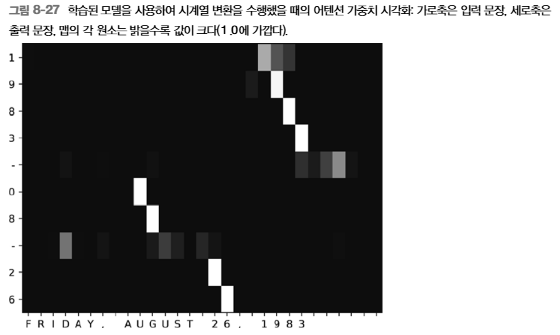   
- 그림은 seq2seq가 시계열 변환을 할 때의 어텐션 가중치를 시각화한 결과
- 예컨대 seq2seq가 최초의 '1'을 출력할 때는 입력 문장의 '1' 위치에 표시가 됨
- 여기서 주목할 점은 년,월,일의 대응 관계
- 이 결과 그래프를 자세히 보면, 세로축(출력)의 '1983'과 '26'이 가로축(입력)의 '1983'과 '26'에 훌륭하게 대응하고 있음
- 더욱이 월을 뜻하는 '08'에 입력 문장의 'AUGUST'가 대응하고 있음
- seq2seq는 'August'가 '8월'에 대응한다는 사실을 데이터만 가지고 학습해낸 것   

다른 예도 몇개 살펴보면, 여기에서도 년,월,일의 대응 관계를 명확히 간파할 수 있음   
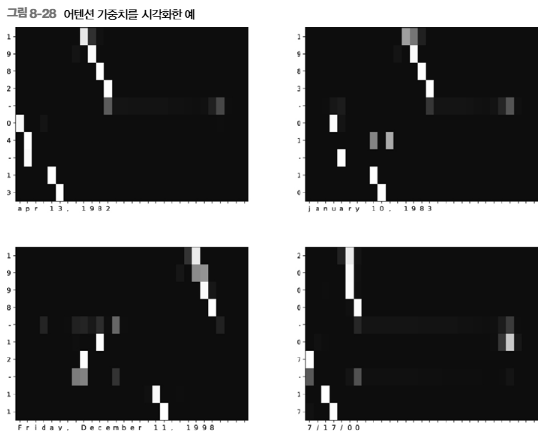   

이처럼 어텐션을 이용하면, seq2seq는 마치 사람이 그러하듯 필요한 정보에 주의를 더 기울일 수 있음   
"어텐션을 통해, 모델이 수행하는 작업을 우리 인간이 이해할 수 있게 되었다"라고도 생각할 수 있음   

> 신경망 내부에서 어떠한 처리를 이뤄지고 있는지(어떠한 논리로 처리되고 있는지)는 인간이 이해할 수 없는 게 일반적   
> 반면 어텐션은 '인간이 이해할 수 있는 구조나 의미'를 모델에 제공함   
> 앞의 예에서는 어텐션을 사용함으로써 단어와 단어의 관련성을 볼 수 있었음   
> 이를 보고 모델의 처리 논리가 인간의 논리를 따르는지를 판단할 수 있음   

## 어텐션에 관한 남은 이야기

지금까지 어텐션에 대해(정확하게는 어텐션을 갖춘 seq2seq에 대해) 살펴봤음   
이번 절에서는 어텐션에 관련하여 지금까지 다루지 못한 주제 몇 가지를 소개

### 양방향 RNN

이번 절은 seq2seq의 Encoder에 초점을 맞춤   
복습해보면, 앞 절까지의 Encoder는 다음처럼 그릴 수 있음   
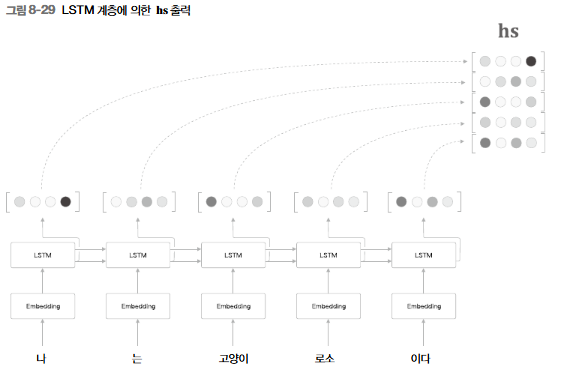   
- 이 그림에서 보듯, LSTM의 각 시각의 은닉 상태 벡터는 hs로 모아짐
- 그리고 Encoder가 출력하는 hs의 각 행에는 그 행에 대응하는 단어의 성분이 많이 포함되어 있음
- 여기서 주목할 것은 사람은 글을 왼쪽에서 오른쪽으로 읽는다는 점
- 따라서 그림의 예에서는 '고양이'에 대응하는 벡터에 '나', '는', '고양이'까지 총 세 단어의 정보가 인코딩되어 들어감
- 여기에서 전체적인 균형을 생각하면, '고양이' 단어의 '주변' 정보를 균형 있게 담고 싶을 것   

> 이번 번역 문제에서 책에서는 시계열 데이터(번역해야 할 문장)를 한꺼번에 건네줌   
> 따라서 문장을 오른쪽부터 읽도록(처리하도록) 할 수도 있음   

그래서 LSTM을 양방향으로 처리하는 방법을 생각할 수 있음   
이것이 **양방향 LSTM(양방향 RNN)** 기술, 그림으로는   
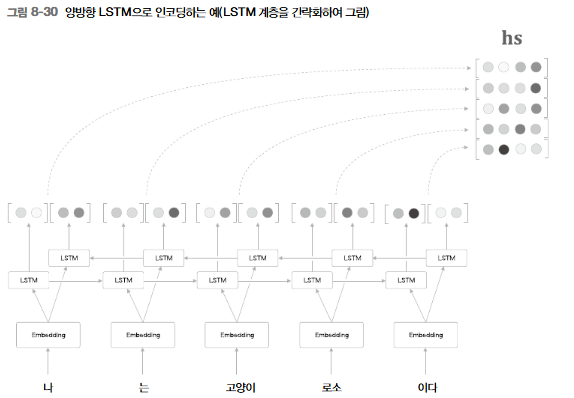   
- 그림에서 보듯, 양방향 LSTM에서는 지금까지의 LSTM 계층에 더해 역방향으로 처리하는 LSTM 계층도 추가
- 그리고 각 시각에서는 이 두 LSTM 계층의 은닉 상태를 연결시킨 벡터를 최종 은닉 상태로 처리('연결' 외에도, '합'하거나 '평균'내는 방법 등도 생각할 수 있음)
- 이처럼 양방향으로 처리함으로써, 각 단어에 대응하는 은닉 상태 벡터에는 좌와 우 양쪽 방향으로부터의 정보를 집약할 수 있음
- 이렇게 해서 균형 잡힌 정보가 인코딩되게 됨   

양방향 LSTM은 구현하기도 쉬움   
- 한 가지 방법은, 2개의 LSTM 계층(여기서는 Time LSTM 계층)을 사용하여 각각의 계층에 주는 단어의 순서를 조정하면 됨
- LSTM 계층 하나는 지금까지와 똑같음
- 즉, 입력 문장을 '왼쪽부터 오른쪽으로' 처리하는 일반적인 LSTM 계층
- 또 하나의 LSTM 계층에는 입력 문장의 단어들을 반대 순서로 나열
- 만약 원래 문장이 "A B C D"였다면 "D C B A"로 순서를 바꾸는 것
- 두 번째 LSTM 계층은 입력문을 '오른쪽에서 왼쪽으로' 처리하게 됨
- 마지막으로 이 두 LSTM 계층의 출력을 연결하기만 하면 양방향 LSTM 계층 완성   

> 이번 장에서는 쉽게 설명하고자 Encoder에는 단방향 LSTM을 이용   
> 하지만 양방향 LSTM을 이용해도 됨

In [17]:
class TimeBiLSTM:
    def __init__(self, Wx1, Wh1, b1,
                 Wx2, Wh2, b2, stateful=False):
        self.forward_lstm = TimeLSTM(Wx1, Wh1, b1, stateful)
        self.backward_lstm = TimeLSTM(Wx2, Wh2, b2, stateful)
        self.params = self.forward_lstm.params + self.backward_lstm.params
        self.grads = self.forward_lstm.grads + self.backward_lstm.grads

    def forward(self, xs):
        o1 = self.forward_lstm.forward(xs)
        o2 = self.backward_lstm.forward(xs[:, ::-1])
        o2 = o2[:, ::-1]

        out = np.concatenate((o1, o2), axis=2)
        return out

    def backward(self, dhs):
        H = dhs.shape[2] // 2
        do1 = dhs[:, :, :H]
        do2 = dhs[:, :, H:]

        dxs1 = self.forward_lstm.backward(do1)
        do2 = do2[:, ::-1]
        dxs2 = self.backward_lstm.backward(do2)
        dxs2 = dxs2[:, ::-1]
        dxs = dxs1 + dxs2
        return dxs

### Attention 계층 사용 방법

이어서 Attention 계층의 사용법   
복습하면 지금까지는 아래 그림과 같은 구성으로 Attention 계층을 이용했음   
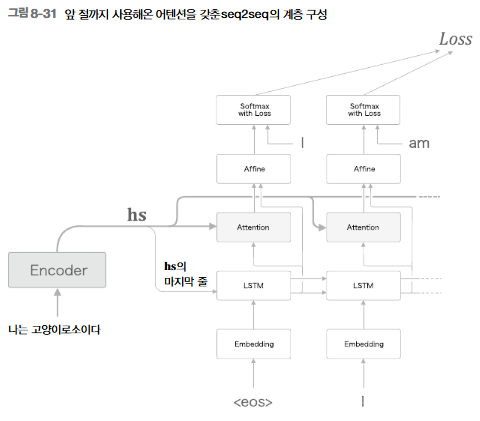   
- 그림에서 보듯, Attention 계층을 LSTM 계층과 Affine 계층 사이에 삽입함
- 그러나 Attention 계층을 이용하는 장소가 반드시 이 그림과 같을 필요는 없음
- 실제로 여러 후보를 생각할 수 있는데, 예컨대 다음처럼 구성 가능   

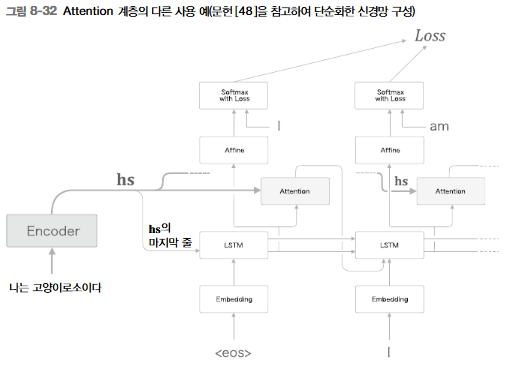   
- 이 그림에서는 Attention 계층의 출력(맥락 벡터)이 다음 시각의 LSTM 계층에 입력되도록 연결됨
- 이렇게 구성하면 LSTM 계층이 맥락 벡터의 정보를 이용할 수 있음
- 한편, 책에서 구현한 모델은 Affine 계층이 맥락 벡터를 이용했음   

그렇다면 Attention 계층의 위치를 달리하는 게 최종 정확도에는 어떤 영향이 주는지   
그 답은 해보지 않으면 모름   
현실은 실제 데이터를 사용해 검증할 수밖에 없음   
다만, 앞의 두 모델은 모두 맥락 벡터를 잘 활용하는 구성이라서 큰 차이가 없을지도 모름   

또한, 구현 관점에서는 전자의 구성(LSTM 계층과 Affine 계층 사이에 Attention 계층을 삽입) 쪽이 구현하기 쉬움   
그리고 전자의 구성에서는 Decoder의 데이터 흐름이 아래에서 위로 가는 한 방향이기 때문에 Attention 계층을 쉽게 모듈화할 수 있음   
실제로도 Time Attention 계층으로 간단히 모듈화할 수 있었음

### seq2seq 심층화와 skip 연결

번역 등 현실에서의 애플리케이션들은 풀어야 할 문제가 훨씬 복잡   
그렇다면 어텐션을 갖춘 seq2seq에도 더 높은 표현력이 요구될 것   
이때 우선 생각해야 할 것은 RNN 계층(LSTM 계층)을 깊게 쌓는 방법   
층을 깊게 쌓으면 표현력 높은 모델을 만들 수 있고, 어텐션을 갖춘 seq2seq도 다르지 않음   
그러면 어텐션을 갖춘 seq2seq를 깊게 하면 어떻게 될지, 이번 절에서는 한 가지로 예로 다음 그림과 같은 구성을 살펴봄   
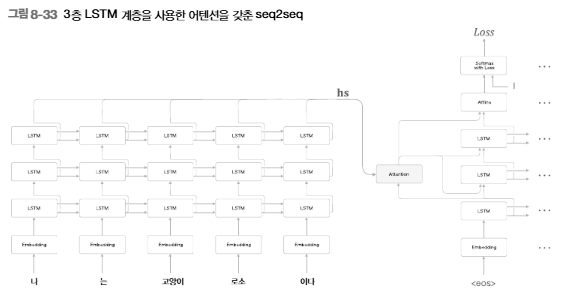   
- 그림의 모델에서는 Encoder와 Decoder로 3층 LSTM 계층을 사용하고 있음
- 이 예처럼 Encoder와 Decoder에서는 같은 층수의 LSTM 계층을 이용하는 것이 일반적
- 한편, Attention 계층의 사용법은 여러 변형이 있을 수 있음
- 여기에서는 Decoder의 LSTM 계층의 은닉 상태를 Attention 계층에 입력하고, Attention 계층의 출력인 맥락 벡터를 Decoder의 여러 계층(LSTM 계층과 Affine 계층)으로 전파   

> 그림의 모델은 하나의 예에 지나지 않음   
> 이 외에도 여러 개의 Attention 계층을 사용하거나, Attention의 출력을 다음 시각의 LSTM 계층으로 입력하는 등 다양한 변형이 가능   
> 또한, 계층을 깊게 할 경우에는 일반화 성능을 떨어뜨리지 않는 것이 중요   
> 이 목적으로는 드롭아웃과 가중치 공유 등의 기술이 효과적   

층을 깊게 할 때 사용되는 중요한 기법 중 **skip 연결(skip connection)** 이 있음('잔차 연결(residual connection)' 혹은 '숏컷(short-cut)'이라고도 함)   
skip 연결은 아래 그림처럼 계층을 넘어 '선을 연결'하는 단순한 기법   
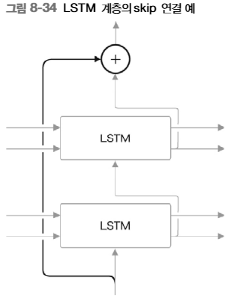   
- 그림에서 보듯, skip 연결은 '계층을 건너뛰는 연결'
- 이때 skip 연결의 접속부에서는 2개의 출력이 '더해'짐
- 이 덧셈(정확하게는 원소별 덧셈)이 핵심
- 왜냐하면 덧셈은 역전파 시 기울기를 '그대로 흘려'보내므로, skip 연결의 기울기가 아무런 영향을 받지 않고 모든 계층으로 흐르기 때문
- 따라서 층이 깊어져도 기울기가 소실(혹은 폭발)되지 않고 전파되어, 결과적으로 좋은 학습을 기대할 수 있음   

> RNN 계층의 역전파에서는 시간 방향에서 기울기 소실 혹은 폭발이 일어날 수 있음   
> 기울기 소실에는 LSTM과 GRU 등의 '게이트가 달린 RNN'으로 대응하고, 기울기 폭발에는 '기울기 클리핑'으로 대응할 수 있었음   
> 한편, RNN의 깊이 방향 기울기 소실에는 skip 연결이 효과적   

## 어텐션 응용

지금까지는 어텐션을 seq2seq에만 적용했음   
하지만 이 아이디어 자체는 범용적이고 더 많은 가능성을 지니고 있음   
실제로 딥러닝 연구에서는 어텐션이 중요한 기술로써 다양한 장면에서 등장함   
이번 절에서는 어텐션의 중요성과 가능성을 느낄 수 있도록 최첨단 연구 3가지를 소개

### 구글 신경망 기계 번역(GNMT)

기계 번역의 역사를 살펴보면, 주요한 기법이 시대의 흐름과 함께 변해왔음을 알 수 있음   
그 흐름은 '규칙 기반 번역'에서 '용례 기반 번역'으로, 다시 '통계 기반 번역'으로 옮겨왔음   
그리고 이 기존 기술들을 대신해 **신경망 기계 번역(Neural Machine Translation)(NMT)** 이 주목받고 있음   

> 신경망 기계 번역이라는 용어는 기존의 통계 기반 번역과 대비되는 형태로 사용되다가, 최근에는 seq2seq를 사용한 기계 번역의 총칭으로서 사용되고 있음   

구글 번역(Google Translate)은 실제로 2016년부터 신경망 번역을 사용하고 있음   
이 기계 번역 시스템은 **구글 신경망 기계 번역(Google Neural Machine Translation)(GNMT)** 이라 불림   
이번 절에서는 GNMT의 아키텍처를 계층 구성 중심으로 살펴봄   
그러면 GNMT의 계층 구성을 먼저 보면   
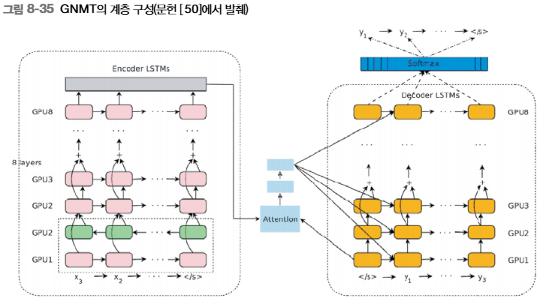   
- GNMT도 이번 장에서 구현한 어텐션을 갖춘 seq2seq와 마찬가지로 Encoder와 Decoder, 그리고 Attention으로 구성
- 다만, 책에서의 단순한 모델과는 달리, 번역 정확도를 높이기 위한 여러 개선이 더해졌음
- 예컨대 LSTM 계층의 다층화, 양방향 LSTM(Encoder의 첫 번째 계층만), skip 연결 등
- 또한, 학습 시간을 단축하기 위해 다수의 GPU로 분산 학습을 수행하고 있음   

GNMT에서는 위의 아키텍처적인 연구 외에도, 낮은 빈도의 단어 처리나 추론 고속화를 위한 양자화 등 다양한 연구가 이뤄지고 있음   
이러한 기술을 활용해 GNMT는 매우 뛰어난 결과를 달성했다는데, 실제로 보고된 결과는   
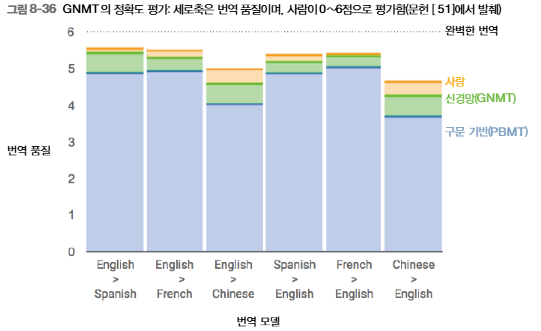   
- 그림에서 보듯, GNMT는 기존 기법(통계 기반 기계 번역의 하나인 '구문 기반 기계 번역')과 비교해 번역 품질을 크게 끌어올리는 데 성공
- 정확도는 무려 '사람(에 의한 번역)'의 정확도에 가까워지고 있음
- 이처럼 GNMT는 훌륭한 결과를 보여주며 신경망 번역의 실용성과 가능성을 입증했음
- 다만, 구글 번역을 사용해보면 알겠지만, 아직도 자연스럽지 못한 번역이나 사람이라면 절대 저지르지 않을 것 같은 실수도 함
- 앞으로도 기계 번역 연구는 계속될 것
- 실제로 GNMT는 시작에 지나지 않고, 현재도 신경망 번역을 중심으로 활발하게 연구가 이뤄지고 있음   

> GNMT를 실제로 구현하려면 대량의 데이터와 대량의 컴퓨팅 자원이 필요   
> 문헌에 따르면 대량의 학습 데이터를 사용했고, 모델 하나를 학습시키는 데 100개 가까운 GPU로 6일이나 걸렸다고 함   
> 8개의 모델을 병행 학습하는 앙상블 학습이나 강화 학습을 이용해 품질을 더욱 개선하려는 연구도 진행되고 있음   
> 이러한 일은 한 개인이 실현할 수 있는 수준은 아님   

### 트랜스포머

지금까지 RNN(LSTM)을 다양한 곳에 사용해왔음   
언어 모델에서 시작하여, 문장 생성, seq2seq, 그리고 어텐션을 갖춘 seq2seq의 구성에는 반드시 RNN이 등장   
그리고 RNN을 통해 가변 길이 시계열 데이터를 잘 처리하여 (많은 경우) 좋은 결과를 얻음   
하지만 RNN에도 단점은 있고, 그중 하나로 병렬 처리를 들 수 있음   

RNN은 이전 시각에 계산한 결과를 이용하여 순서대로 계산함   
따라서 RNN의 계산을 시간 방향으로 병렬 계산하기란 (기본적으로는) 불가능   
이 점은 딥러닝 학습이 GPU를 사용한 병렬 계산 환경에서 이뤄진다는 점을 생각하면 큰 병목   
그래서 RNN 사용을 피하고 싶을 수 있음   

이러한 배경에서, 현재는 RNN을 없애는 연구(혹은 병렬 계산할 수 있는 RNN 연구)가 활발히 이뤄지고 있음   
그중에서 유명한 것이「Attention is all you need」라는 논문에서 제안한 기법인 트랜스포머(Transformer) 모델   
논문 제목이 말해주듯 이 모델은 'RNN이 아닌' 어텐션을 사용해 처리함   
이번 절에서는 이 트랜스포머를 간단히 살펴봄   

> 트랜스포머 외에도 RNN을 제거하는 연구는 다양하게 시도되고 있음   
> 그 성과의 하나로 RNN 대신 합성곱 계층을 이용하는 연구가 있음   
> 이 연구의 자세한 내용은 여기에서 다루지 않지만, 기본적으로는 RNN 대신 합성곱 계층을 이용해 seq2seq를 구성함   
> 이렇게 하면 계산을 병렬화할 수 있음   

트랜스포머는 어텐션으로 구성되는데, 그중 **셀프어텐션(Self-Attention)** 이라는 기술을 이용하는 게 핵심   
Self-Attention은 직역하면 '자신에 대한 주목'   
즉, 하나의 시계열 데이터를 대상으로 한 어텐션으로, '하나의 시계열 데이터 내에서' 각 원소가 다른 원소들과 어떻게 관련되는지를 살펴보자는 취지   
Time Attention 계층을 예로 설명하면, 셀프어텐션은 다음처럼 그릴 수 있음   
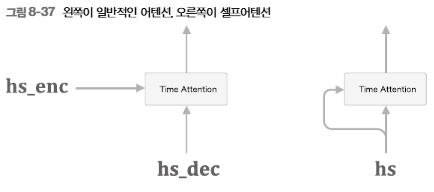   
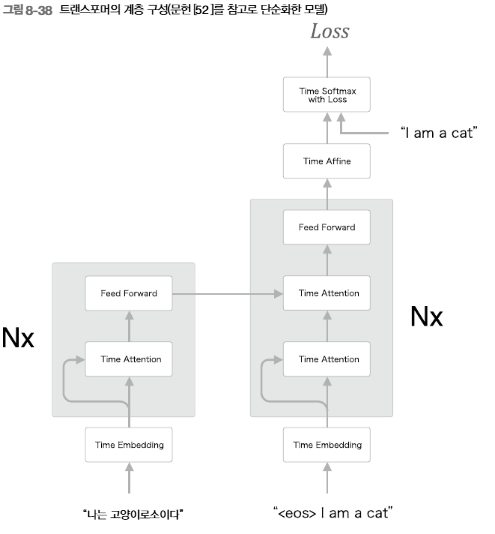   
지금까지는 어텐션에서 '번역'과 같이 2개의 시계열 데이터 사이의 대응 관계를 구해왔음   
이때 Time Attention 계층에는 그림의 왼쪽처럼 서로 다른 두 시계열 데이터가 입력됨   
반면, Self-Attention은 그림의 오른쪽처럼 두 입력선이 모두 하나의 시계열 데이터로부터 나옴   
이렇게 하면 하나의 시계열 데이터 내에서의 원소 간 대응 관계가 구해짐   

계속해서 트랜스포머의 계층 구성을 살펴보면(그림 중 아래 그림)   
- 트랜스포머에서는 RNN 대신 어텐션을 사용   
- 실제로 그림을 보면 Encoder와 Decoder 모두에서 셀프어텐션을 사용함   
- 또한 그림의 Feed Forward 계층은 피드포워드 신경망(시간 방향으로 독립적으로 처리하는 신경망)을 나타냄
- 정확하게는 은닉층이 1개이고 활성화 함수로 ReLU를 이용한 완전연결계층 신경망을 이용함
- 또한, 그림에서 Nx는 회색 배경으로 둘러쌓인 계층들을 N겹 쌓았다는 뜻   

> 그림은 트랜스포머를 단순화해 보여줌   
> 실제로는 이 그림의 아키텍처에 더해 skip 연결과 계층 정규화(Layer Normalization) 등도 이용함   
> 다수의 어텐션을 (병렬로) 이용하거나 시계열 데이터의 위치 정보를 인코딩하는 위치 인코딩(Positional Encoding) 같은 기법도 볼 수 있음   

트랜스포머를 이용하면 계산량을 줄이고 GPU를 이용한 병렬 계산의 혜택도 더 많이 누릴 수 있음   
그 결과 트랜스포머는 GNMT보다 학습 시간을 큰 폭으로 줄이는 데 성공함   
번역 품질도 상당 폭 끌어올릴 수 있음   
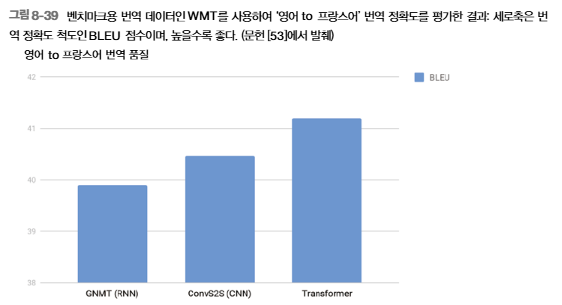   
- 그림에서는 세 가지 기법을 비교
- 그 결과 GNMT보다 '합성곱 계층을 이용한 seq2seq'(그림에서는 ConvS2S로 표기)가 더 정확하며, 트랜스포머는 둘 모두를 웃돌고 있음
- 이처럼 어텐션은 계산량은 물론 정확도 측면에서도 유망한 기술임을 알 수 있음   

지금까지는 어텐션을 RNN과 조합해 이용해왔음   
그러나 이번 절의 연구가 시사하는 것처럼 어텐션은 RNN을 대체하는 모듈로도 이용할 수 있음   
그렇다면 어텐션을 이용할 기회가 앞으로 더 늘어날지도 모름

### 뉴럴 튜링 머신(NTM)

인간은 복잡한 문제를 풀 때 '종이'와 '펜'을 사용하는 일이 많음   
달리 보면 종이와 펜이라는 외부의 '저장 장치' 덕분에 능력이 확장되었다고도 해석할 수 있음   
신경망에도 이와 같은 '외부 메모리'를 이용하여 새로운 힘을 부여할 수 있음   
그래서 이번 절에서 다룰 주제는 바로 '외부 메모리를 통한 확장'   

> RNN이나 LSTM은 내부 상태를 활용하여 시계열 데이터를 기억할 수 있음   
> 그러나 그 내부 상태는 길이가 고정이라서 채워 넣을 수 있는 정보량이 제한적   
> 그래서 RNN 외부에 기억 장치(메모리)를 두고 필요한 정보를 거기에 적절하게 기록하는 방안을 착안해낸 것   

어텐션을 갖춘 seq2seq에서는 Encoder가 입력 문장을 인코딩함   
그리고 인코딩된 정보를 어텐션을 통해 Decoder가 이용   
여기서 주목할 것은 역시 어텐션의 존재   
이 어텐션을 통해 Encoder와 Decoder는 (컴퓨터에서 말하는) '메모리 조작' 같은 작업을 수행하는 것   
즉, Encoder가 필요한 정보를 메모리에 쓰고, Decoder는 그 메모리로부터 필요한 정보를 읽어 들인다고 해석할 수 있음   

이렇게 생각하면 컴퓨터의 메모리 조작을 신경망에서도 재현할 수 있을 것처럼 보임   
바로 생각할 수 있는 방법은 RNN의 외부에 정보 저장용 메모리 기능을 배치하고, 어텐션을 이용하여 그 메모리로부터 필요한 정보를 읽거나 쓰는 방법   
실제로 이러한 연구가 몇 가지 이뤄지고 있고, 그중 유명한 연구가 **뉴럴 튜링 머신(Neural Turing Machine)(NTM)**   

> NTM은 딥마인드(DeepMind) 팀에서 진행한 연구이며, 후에 **DNC(Differentiable Neural Computers)** 라는 기법으로 개선한 논문이 과학 잡지『네이처Nature』에 실렸음   
> DNC는 NTM의 메모리 조작을 더욱 강화한 버전이라고 볼 수 있으나 본질적인 기술은 같음   

NTM의 내용을 자세히 설명하기 전에, 우선 큰 틀을 살펴보면   
이 용도로 아주 잘 어울리는 것이 바로 아래 그림   
이 그림은 NTM 처리의 핵심을 잘 정리해 시각화함(정확하게는 NTM를 발전시킨 DNC의 해설 기사에서 사용한 그림)   
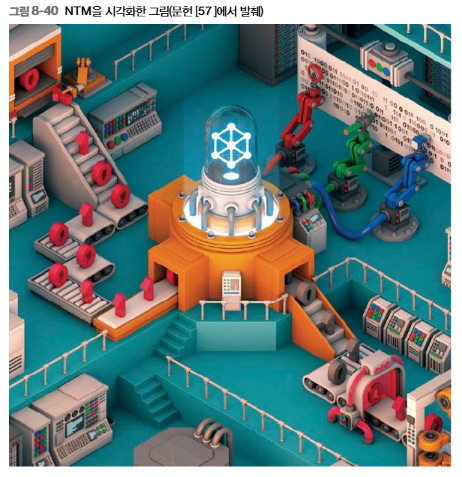   
- 이 그림을 눈여겨 살펴보면
- 여기서 주목할 것은 그림 한가운데 있는 '컨트롤러'라는 모듈
- 정보를 처리하는 모듈로, 신경망(혹은 RNN)을 이용하는 것으로 예상됨
- 그림을 보면, 이 컨트롤러는 차례차례 흘러 들어오는 '0' 혹은 '1' 데이터를 처리하여 새로운 데이터를 출력하고 있음
- 여기서 중요한 것이, 이 컨트롤러의 바깥(그림에서 오른쪽 위)에 있는 '큰 종이(=메모리)'의 존재
- 이 메모리 덕분에 컨트롤러는 컴퓨터(혹은 튜링 머신)와 같은 능력을 얻음
- 그 능력이란 바로 '큰 종이'에 필요한 정보를 쓰거나 불필요한 정보를 지우는 능력, 그리고 필요한 정보를 다시 읽어 들이는 능력
- 그리고 그림의 '큰 종이'는 두루마리 형태인데, 각 노드가 필요한 위치의 데이터를 읽고 쓸 수 있다는 뜻
- 다시 말해, 원하는 목적지로 이동할 수 있음   

이처럼 NTM은 외부 메모리를 읽고 쓰면서 시계열 데이터를 처리함   
그리고 또 하나 재미있는 사실은 이러한 메모리 조작을 '미분 가능'한 계산으로 구축했다는 점   
따라서 메모리 조작 순서도 데이터로부터 학습할 수 있음   

> 일반적인 컴퓨터는 사람이 작성한 지시(프로그램)에 따라 동작하는 데 반해, NTM은 데이터로부터 프로그램을 학습함   
> 즉, '알고리즘의 입력과 출력'으로부터 '알고리즘 자체(로직)'를 학습할 수 있다는 뜻   

NTM은 외부 메모리에 (컴퓨터처럼) 읽고 쓰기를 수행함   
이러한 NTM의 계층 구성을 간단히 그리면   
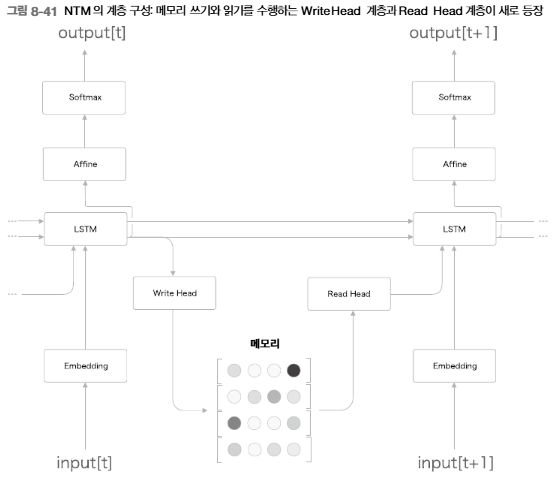   
- 그림은 간략화한 NTM의 계층 구성
- 여기서 LSTM 계층이 '컨트롤러'가 되어 NTM의 주된 처리를 수행
- 그리고 각 시각에서 LSTM 계층의 은닉 상태를 Write Head 계층이 받아서 필요한 정보를 메모리에 씀
- 그런 다음 Read Head 계층이 메모리로부터 중요한 정보를 읽어 들여 다음 시각의 LSTM 계층으로 전달   

그런데 그림의 Write Head 계층과 Read Head 계층은 어떻게 메모리를 조작하는지?   
물론 여기에도 어텐션을 사용   

> 반복되지만, 메모리의 특정 번지에 담긴 데이터를 읽거나 쓰려할 때, 데이터를 '선택'해야 하는데, 이 선택 작업 자체는 미분할 수 없음   
> 그래서 어텐션을 사용하여 모든 번지에 담긴 데이터를 선택하도록 하고, 각 데이터의 기여도를 나타내는 '가중치'를 이용하는 것   
> 이렇게 함으로써 '선택한다'라는 작업을 미분 가능한 계산으로 대체할 수 있음   

NTM은 컴퓨터의 메모리 조작을 모방하기 위해서 2개의 어텐션을 이용   
- '콘텐츠 기반 어텐션'과 '위치 기반 어텐션'   
- 콘텐츠 기반 어텐션은 지금까지 본 어텐션과 같고, 입력으로 주어진 어느 벡터(질의(query) 벡터)와 비슷한 벡터를 메모리로부터 찾아내는 용도로 이용됨
- 위치 기반 어텐션은 이전 시각에서 주목한 메모리의 위치(=메모리의 각 위치에 대한 가중치)를 기준으로 그 전후로 이동(시프트)하는 용도로 사용됨
- 이 기술의 자세한 설명은 생략하지만, 1차원의 합성곱 연산으로 구현됨
- 메모리 위치를 시프트하는 이 기능을 사용하면 메모리 위치를 하나씩 옮겨가며 읽어 나가는 컴퓨터 특유의 움직임을 쉽게 재현할 수 있음   

> NTM의 메모리 조작은 다소 복잡   
> 앞에서 설명한 조작 외에도 어텐션의 가중치를 날카롭게 다듬는 처리, 이전 시각 어텐션의 가중치를 더해주는 처리 등도 이뤄짐   

이처럼 외부 메모리를 자유롭게 이용하게 됨으로써 NTM은 큰 힘을 손에 넣게 됨   
실제로 seq2seq만으로는 풀리지 않던 복잡한 문제에서도 NTM은 놀라운 성과를 거둠   
구체적으로는 긴 시계열을 기억하는 문제와 정렬(=수들을 크기 순으로 나열) 등의 문제를 NTM은 보기 좋게 해결하고 있음   

또한, NTM은 외부 메모리를 사용함으로써 알고리즘을 학습하는 능력을 얻음   
그리고 이때 어텐션이 중요한 기술로써 이용됨   
외부 메모리에 의한 확장, 그리고 어텐션은 앞으로 더욱 중요한 기법으로써 다양한 장소에서 이용될 것

## 정리

이번 장에서는 어텐션의 구조를 배우고, Attention 계층을 구현함   
그리고 어텐션을 이용한 seq2seq를 구현하고 간단한 실험을 통해 어텐션의 뛰어난 효과를 확인함   
또한 모델이 추론할 때의 어텐션 가중치(확률)를 시각화   
그 결과, 어텐션을 갖춘 모델은 인간처럼 필요한 정보에 주목하고 있음을 알 수 있음   

또한, 어텐션을 중심으로 한 최첨단 연구의 동향도 소개함   
그 예들을 보면서 어텐션 덕분에 딥러닝의 가능성이 한층 더 넓어졌음을 알 수 있음   
이처럼 어텐션은 응용하기 좋은 기술이며, 많은 가능성을 지니고 있음   
딥러닝 분야에서는 앞으로도 어텐션 자체가 많은 '주목'을 끌 것

### 이번 장에서 배운 내용

- 번역이나 음성 인식 등, 한 시계열 데이터를 다른 시계열 데이터로 변환하는 작업에서는 시계열 데이터 사이의 대응 관계가 존재하는 경우가 많음
- 어텐션은 두 시계열 데이터 사이의 대응 관계를 데이터로부터 학습함
- 어텐션에서는 (하나의 방법으로서) 벡터의 내적을 사용해 벡터 사이의 유사도를 구하고, 그 유사도를 이용한 가중합 벡터가 어텐션의 출력이 됨
- 어텐션에서 사용하는 연산은 미분 가능하기 때문에 오차역전파법으로 학습할 수 있음
- 어텐션이 산출하는 가중치(확률)를 시각화하면 입출력의 대응 관계를 볼 수 있음
- 외부 메모리를 활용한 신경망 확장 연구 예에서는 메모리를 읽고 쓰는 데 어텐션을 사용함